<a href="https://colab.research.google.com/github/jeffersonramelo/Analise_DCs/blob/main/AVeAH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd



In [33]:
df = pd.read_csv("/content/DadosFiciticia.csv",
                 sep=';',
                 decimal=',',   # vírgula é decimal
                 thousands='.' # ponto é milhar
)
df


,classificacao,conta,ano1,ano2
0,ativo,ativo circulante,27050,30700
1,ativo,caixa e equivalentes de caixa,7400,5440
2,ativo,aplicações financeiras,5750,3860
3,ativo,contas a eeceber,2900,4760
4,ativo,estoques,6400,9700
5,ativo,tributos a recuperar,3200,4450
6,ativo,despesas antecipadas,1400,2490
7,ativo,ativo não circulante,14135,16475
8,ativo,ativo realizável a longo prazo,1700,1850
9,ativo,investimentos,3540,4865


In [34]:
### analise horizontal:
df["ah(%)"] = (((df["ano2"] / df["ano1"]) - 1) * 100).round(2)
df

,classificacao,conta,ano1,ano2,ah(%)
0,ativo,ativo circulante,27050,30700,13.49
1,ativo,caixa e equivalentes de caixa,7400,5440,-26.49
2,ativo,aplicações financeiras,5750,3860,-32.87
3,ativo,contas a eeceber,2900,4760,64.14
4,ativo,estoques,6400,9700,51.56
5,ativo,tributos a recuperar,3200,4450,39.06
6,ativo,despesas antecipadas,1400,2490,77.86
7,ativo,ativo não circulante,14135,16475,16.55
8,ativo,ativo realizável a longo prazo,1700,1850,8.82
9,ativo,investimentos,3540,4865,37.43


In [35]:
### analise vertical:
# capturar totais
total_ativo_ano1 = df.loc[df["conta"] == "total ativo", "ano1"].iloc[0]
total_ativo_ano2 = df.loc[df["conta"] == "total ativo", "ano2"].iloc[0]

total_passivo_ano1 = df.loc[df["conta"] == "total passivo pl", "ano1"].iloc[0]
total_passivo_ano2 = df.loc[df["conta"] == "total passivo pl", "ano2"].iloc[0]

df["av_ano1(%)"] = 0.0
df["av_ano2(%)"] = 0.0

df.loc[df["classificacao"] == "ativo", "av_ano1(%)"] = (df["ano1"] / total_ativo_ano1 * 100).round(2)
df.loc[df["classificacao"] == "ativo", "av_ano2(%)"] = (df["ano2"] / total_ativo_ano2 * 100).round(2)

df.loc[df["classificacao"] == "passivoepl", "av_ano1(%)"] = (df["ano1"] / total_passivo_ano1 * 100).round(2)
df.loc[df["classificacao"] == "passivoepl", "av_ano2(%)"] = (df["ano2"] / total_passivo_ano2 * 100).round(2)

df


,classificacao,conta,ano1,ano2,ah(%),av_ano1(%),av_ano2(%)
0,ativo,ativo circulante,27050,30700,13.49,65.68,65.08
1,ativo,caixa e equivalentes de caixa,7400,5440,-26.49,17.97,11.53
2,ativo,aplicações financeiras,5750,3860,-32.87,13.96,8.18
3,ativo,contas a eeceber,2900,4760,64.14,7.04,10.09
4,ativo,estoques,6400,9700,51.56,15.54,20.56
5,ativo,tributos a recuperar,3200,4450,39.06,7.77,9.43
6,ativo,despesas antecipadas,1400,2490,77.86,3.40,5.28
7,ativo,ativo não circulante,14135,16475,16.55,34.32,34.92
8,ativo,ativo realizável a longo prazo,1700,1850,8.82,4.13,3.92
9,ativo,investimentos,3540,4865,37.43,8.60,10.31


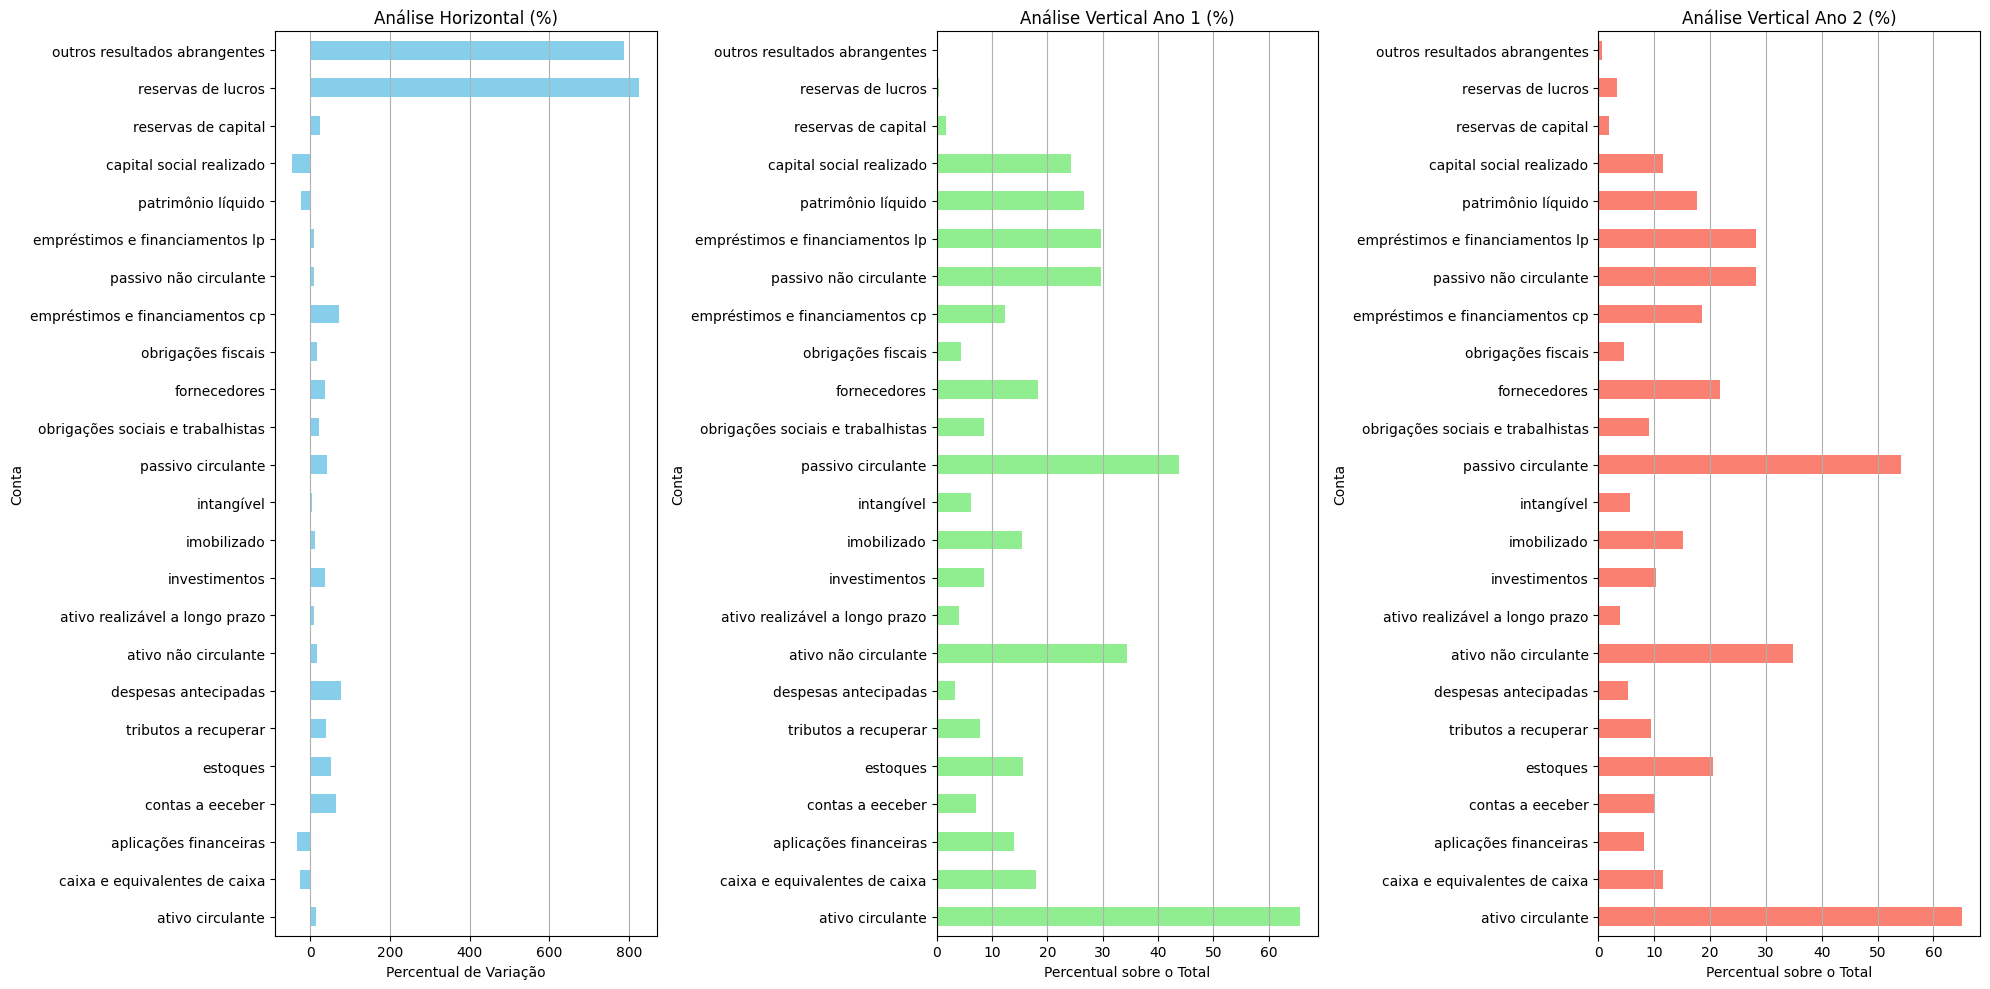

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# Filter out the total rows as they distort the visualization
df_filtered = df[~df['conta'].isin(['total ativo', 'total passivo pl'])]

# Set the index to 'conta' for easier plotting
df_filtered = df_filtered.set_index('conta')

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))

# Plot the horizontal analysis
df_filtered['ah(%)'].plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Análise Horizontal (%)')
axes[0].set_xlabel('Percentual de Variação')
axes[0].set_ylabel('Conta')
axes[0].grid(axis='x')

# Plot the vertical analysis for Ano1
df_filtered['av_ano1(%)'].plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_title('Análise Vertical Ano 1 (%)')
axes[1].set_xlabel('Percentual sobre o Total')
axes[1].set_ylabel('Conta')
axes[1].grid(axis='x')

# Plot the vertical analysis for Ano2
df_filtered['av_ano2(%)'].plot(kind='barh', ax=axes[2], color='salmon')
axes[2].set_title('Análise Vertical Ano 2 (%)')
axes[2].set_xlabel('Percentual sobre o Total')
axes[2].set_ylabel('Conta')
axes[2].grid(axis='x')

plt.tight_layout()
plt.show()